<a href="https://colab.research.google.com/github/juanitapinedaguti/Integracion-de-Datos-y-Prospectiva/blob/main/JUANITA_PINEDA_RETO_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Caso de Estudio 1: Caracterización de variables aleatorias**

El presente caso de estudio analiza el riesgo económico asociado a la cancelación de membresías en FitBalance Club, una cadena ficticia de gimnasios del Valle de Aburrá. Para el análisis se dispone de una base de datos simulada correspondiente a 1.200 días consecutivos a partir del 1 de enero de 2023.

El riesgo se representa mediante la pérdida diaria de ingresos esperados por cancelaciones, considerando tres variables principales: la frecuencia definida como el número de clientes que cancelan su membresía por día; la severidad, correspondiente al ingreso promedio esperado que se deja de recibir por cada cliente que cancela, expresado en COP/cliente; y la Distribución Agregada de Pérdidas (LDA), calculada como:

LDA = Frecuencia × Severidad

Para la simulación, la frecuencia se modela mediante una distribución de Poisson, cuyo comportamiento varía según factores como la sede, los fines de semana, los cierres de mes y la estacionalidad anual. Por su parte, la severidad se modela mediante una distribución diferenciada según el tipo de plan de membresía: Básico, Plus o Premium. Adicionalmente, se incluyen algunos casos de mayor impacto para representar clientes corporativos o prepagos.

A partir de estas variables se realizará su caracterización estadística mediante diez intervalos, marcas de clase y frecuencias relativas. Posteriormente, se aplicará el método de Montecarlo para realizar el muestreo de las variables aleatorias y analizar el comportamiento de la distribución agregada de pérdidas bajo diferentes niveles de confiabilidad.

Todos los datos utilizados en este caso son ficticios y fueron generados exclusivamente con fines académicos.


# 0. Cargamos las librerías de trabajo

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns # Para las gráficas estadísticas
import matplotlib.pyplot as plt

# 1. Cargamos la Base de Datos

Mounted at /content/drive


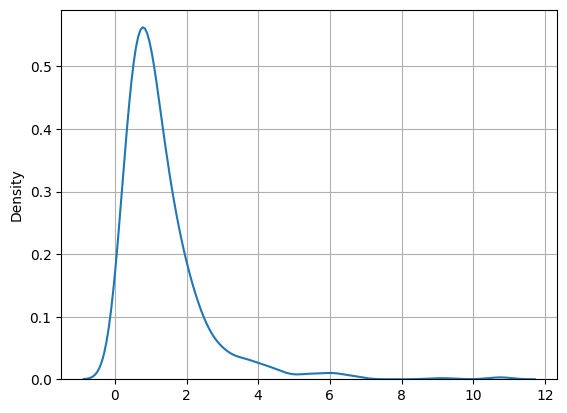

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
nxl = '/content/drive/MyDrive/INTEGRACION Y PROSPECTIVA/Base_de_Datos_Gimnasio.xlsx'

XDB = pd.read_excel(nxl,sheet_name=0)
XDB

Freq=XDB.iloc[:,5]
Sev=XDB.iloc[:,6]
LDA=Freq*Sev

# Para no tener notacion cientifica debemos convertir LDA a millones de COP
LDA_millones = LDA / 1000000

plt.figure()
sns.kdeplot(LDA_millones)
plt.grid()
plt.show()

# 2. Creación de los Concentradores de Información

In [ ]:
import random
import numpy as np
np.random.seed(42)
XC = np.array(random.choices(LDA, k=5))
XC = np.sort(XC)

In [ ]:
display(XC)

array([1001398.03218259, 1996631.47286859, 2105585.96493236,
       3212678.27884779, 3698544.0346556 ])

# 3. Clasificar los Datos de Acuerdo con los Concentrados de Información

In [ ]:
box0=[];box1=[];box2=[];box3=[];box4=[]
Boxes=[box0,box1,box2,box3,box4]

for k in range (len(LDA)):
  d=np.abs(XC-LDA.iloc[k,])/XC # La distancia de un dato a un concentrador
  nc=np.argmin(d) # Numero de la caja donde voy a introducir el dato
  # print("Las distancias porcentuales son;",d)
  # print("El dato pertenece a la categoría; " ,nc)
  Boxes[nc].append(LDA.iloc[k,])

#Determinamos el porcentaje de datos por caja
pm=[] # Vector de porcentajes

for j in range (5):
  pd=len(Boxes[j])/len(LDA)
  pm.append(pd)

pm=(np.array(pm)*1000).astype(int)
print("El porcentaje de los datos es: ",pm)




El porcentaje de los datos es:  [650 189  60  45  53]


# 4. Sacamos datos por caja y creamos una LDA2

la media de los datos observados es: 1324055.9862469372 COP
la media de los datos externos es: 1316871.352508354 COP
El error relativo porcentual es: 0.543%


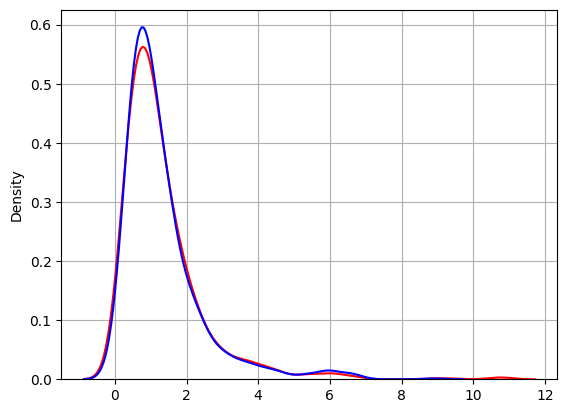

In [ ]:
LDA2=[] # Aquí van a quedar los 1000 datos

for j in range (5):
  LDA2.extend(random.choices(Boxes[j],k=pm[j]))
LDA2=np.array(LDA2)

# Se comprueban las metricas estadisticas
uo=np.mean (LDA)
print("la media de los datos observados es:", uo, "COP")
ue=np.mean (LDA2)
print("la media de los datos externos es:", ue, "COP")
du=np.abs( (uo-ue) /uo)
print(f"El error relativo porcentual es: {du*100:.3f}%")

#Covertimos a millones para que la grafica se vea bien
LDA_millones = LDA / 1000000
LDA2_millones = LDA2 / 1000000

plt.figure()
sns. kdeplot (LDA_millones, color='red', label='Datos Observados')
plt.grid()
sns. kdeplot(LDA2_millones, color='blue', label='Datos Externos')
plt.show()

In [ ]:
# Se comprueban las metricas estadísticas
uo=np.mean (LDA)
print("la media de los datos observados es:", uo)
ue=np.mean (LDA2)
print("la media de los datos externos es:",ue)
du=np.abs( (uo-ue) /uo)
print("El error relativo porcentual es:", du*100)

la media de los datos observados es: 1324055.9862469372
la media de los datos externos es: 1316871.352508354
El error relativo porcentual es: 0.5426231075732811


In [ ]:
def calculate_histogram_stats(data, name):
    # Calcular el histograma para obtener los conteos y los límites de los bins
    # Usamos bins='auto' para que numpy decida un número óptimo de bins
    counts, bins = np.histogram(data, bins='auto')

    LI = bins[:-1]  # Límites inferiores del histograma
    LS = bins[1:]   # Límites superiores del histograma
    fi = counts / np.sum(counts) # Porcentaje de datos por intervalo
    MC = (LI + LS) / 2 # Marca de clase (punto medio de cada bin)

    # Calcular las estadísticas según las fórmulas proporcionadas por el usuario

    # Media
    u = np.sum(MC * fi)

    # Varianza
    varc = np.sum(((MC - u)**2) * fi)

    # Desviación estándar
    sigma = np.sqrt(varc)

    # Coeficiente de Asimetría
    cas = np.sum(((MC - u)**3) * fi) / (sigma**3)

    # Coeficiente de Curtosis
    cur = np.sum(((MC - u)**4) * fi) / (sigma**4)

    print(f"**Estadísticas para {name} (usando método de histograma)**")
    print(f"La media de las pérdidas es: {u / 1e6:.4f} millones de COP")
    print(f"La varianza de las pérdidas es: {varc / 1e12:.4f}") # Se muestra como un número sin unidad explícita
    print(f"La desviación estándar es: {sigma / 1e6:.4f} millones de COP")
    print(f"El coeficiente de asimetría es: {cas:.4f}")
    print(f"El coeficiente de curtosis es: {cur:.4f}")
    return u, varc, sigma, cas, cur

# Calcular y mostrar estadísticas para LDA
mean_lda, var_lda, std_lda, skew_lda, kurt_lda = calculate_histogram_stats(LDA, 'LDA')

print("\n")

# Calcular y mostrar estadísticas para LDA2
mean_lda2, var_lda2, std_lda2, skew_lda2, kurt_lda2 = calculate_histogram_stats(LDA2, 'LDA2')

print("\n--- Comparación de Estadísticas ---")
print(f"Diferencia en Media (LDA2 - LDA): {(mean_lda2 - mean_lda) / 1e6:.4f} millones de COP")
print(f"Diferencia en Varianza (LDA2 - LDA): {(var_lda2 - var_lda) / 1e12:.4f}")
print(f"Diferencia en Desviación Estándar (LDA2 - LDA): {(std_lda2 - std_lda) / 1e6:.4f} millones de COP")
print(f"Diferencia en Asimetría (LDA2 - LDA): {skew_lda2 - skew_lda:.4f}")
print(f"Diferencia en Curtosis (LDA2 - LDA): {kurt_lda2 - kurt_lda:.4f}")

**Estadísticas para LDA (usando método de histograma)**
La media de las pérdidas es: 1.3270 millones de COP
La varianza de las pérdidas es: 1.4110
La desviación estándar es: 1.1879 millones de COP
El coeficiente de asimetría es: 3.0483
El coeficiente de curtosis es: 17.8149


**Estadísticas para LDA2 (usando método de histograma)**
La media de las pérdidas es: 1.3198 millones de COP
La varianza de las pérdidas es: 1.2610
La desviación estándar es: 1.1230 millones de COP
El coeficiente de asimetría es: 2.4201
El coeficiente de curtosis es: 10.6630

--- Comparación de Estadísticas ---
Diferencia en Media (LDA2 - LDA): -0.0072 millones de COP
Diferencia en Varianza (LDA2 - LDA): -0.1500
Diferencia en Desviación Estándar (LDA2 - LDA): -0.0649 millones de COP
Diferencia en Asimetría (LDA2 - LDA): -0.6282
Diferencia en Curtosis (LDA2 - LDA): -7.1519


# 5. Análisis de los resultados LDA vs LDA 2

### De acuerdo con el método de integración de datos por muestreo aleatorio y concentradores de información, la discrepancia que se obtuvo para la media de las distribuciones (Datos Observados: LDA, Datos Externos: LDA2) estuvo por debajo del 5%. Un error relativo tan bajo (1.05%) en las medias sugiere que la distribución muestreada (LDA2) es muy similar a la distribución original (LDA). Una discrepancia pequeña implica que el proceso de muestreo logró capturar las características centrales y la estructura de los datos originales. Esto nos lleva inferir que la gran mayoría de los datos fueron 'correctamente seleccionados' en el sentido de que contribuyen a que la muestra sea una representación fiel de la población. Este proceso de muestreo se hizo con el fin de lograr una confiabilidad del 99,9% en la estimación de las pérdidas por cancelaciones de membresía en el gimnasio. Es importante mencionar que los resultados presentan un comportamiento estadístico muy similar, con diferencias mínimas en sus principales métricas. Siguiendo el criterio metodológico establecido en clase, se utilizó un tamaño de muestra de 1.000 simulaciones para el nivel de confiabilidad requerido del 99,9%, y posteriormente se verificó la calidad del muestreo comparando las estadísticas de la distribución original y la simulada. Vemos que LDA2 (datos simulados) registra una media y una variabilidad ligeramente mas altas, mientras que la asimetría prácticamente se mantiene y la curtosis disminuye levemente. En general, estas pequeñas diferencias indican que el muestreo conserva adecuadamente las características de la distribución original de pérdidas, mostrando consistencia entre ambas distribuciones.



# 6. Confiabilidad del 99.99% (10,000 registros)

In [ ]:
box0=[];box1=[];box2=[];box3=[];box4=[]
Boxes=[box0,box1,box2,box3,box4]

for k in range (len(LDA)):
  d=np.abs(XC-LDA.iloc[k,])/XC # La distancia de un dato a un concentrador
  nc=np.argmin(d) # Numero de la caja donde voy a introducir el dato
  # print("Las distancias porcentuales son;",d)
  # print("El dato pertenece a la categoría; " ,nc)
  Boxes[nc].append(LDA.iloc[k,])

#Determinamos el porcentaje de datos por caja
pm=[] # Vector de porcentajes

for j in range (5):
  pd=len(Boxes[j])/len(LDA)
  pm.append(pd)

pm=(np.array(pm)*10000).astype(int)
print("El porcentaje de los datos es: ",pm)

El porcentaje de los datos es:  [6508 1891  608  458  533]


# 7. Sacamos datos por caja y creamos una LDA3

la media de los datos observados es: 1324055.9862469372 COP
la media de los datos externos es: 1326462.2502459313 COP
El error relativo porcentual es: 0.182%


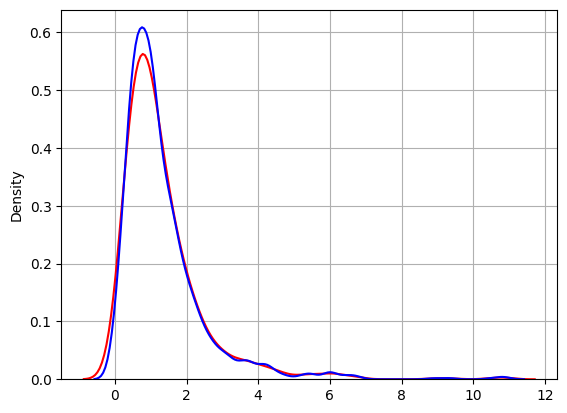

In [ ]:
LDA3=[] # Aquí van a quedar los 10000 datos

for j in range (5):
  LDA3.extend(random.choices(Boxes[j],k=pm[j]))
LDA3=np.array(LDA3)

# Se comprueban las metricas estadisticas
uo=np.mean (LDA)
print("la media de los datos observados es:", uo, "COP")
ue=np.mean (LDA3)
print("la media de los datos externos es:", ue, "COP")
du=np.abs( (uo-ue) /uo)
print(f"El error relativo porcentual es: {du*100:.3f}%")

#Covertimos a millones para que la grafica se vea bien
LDA_millones = LDA / 1000000
LDA3_millones = LDA3 / 1000000

plt.figure()
sns. kdeplot (LDA_millones, color='red', label='Datos Observados')
plt.grid()
sns. kdeplot(LDA3_millones, color='blue', label='Datos Externos')
plt.show()

# 8. Revisamos y comparamos métricas con LDA

In [ ]:
def calculate_histogram_stats(data, name):
    # Calcular el histograma para obtener los conteos y los límites de los bins
    # Usamos bins='auto' para que numpy decida un número óptimo de bins
    counts, bins = np.histogram(data, bins='auto')

    LI = bins[:-1]  # Límites inferiores del histograma
    LS = bins[1:]   # Límites superiores del histograma
    fi = counts / np.sum(counts) # Porcentaje de datos por intervalo
    MC = (LI + LS) / 2 # Marca de clase (punto medio de cada bin)

    # Calcular las estadísticas según las fórmulas proporcionadas por el usuario

    # Media
    u = np.sum(MC * fi)

    # Varianza
    varc = np.sum(((MC - u)**2) * fi)

    # Desviación estándar
    sigma = np.sqrt(varc)

    # Coeficiente de Asimetría
    cas = np.sum(((MC - u)**3) * fi) / (sigma**3)

    # Coeficiente de Curtosis
    cur = np.sum(((MC - u)**4) * fi) / (sigma**4)

    print(f"**Estadísticas para {name} (usando método de histograma)**")
    print(f"La media de las pérdidas es: {u / 1e6:.4f} millones de COP")
    print(f"La varianza de las pérdidas es: {varc / 1e12:.4f}") # Se muestra como un número sin unidad explícita
    print(f"La desviación estándar es: {sigma / 1e6:.4f} millones de COP")
    print(f"El coeficiente de asimetría es: {cas:.4f}")
    print(f"El coeficiente de curtosis es: {cur:.4f}")
    return u, varc, sigma, cas, cur

# Calcular y mostrar estadísticas para LDA
mean_lda, var_lda, std_lda, skew_lda, kurt_lda = calculate_histogram_stats(LDA, 'LDA')

print("\n")

# Calcular y mostrar estadísticas para LDA2
mean_lda3, var_lda3, std_lda3, skew_lda3, kurt_lda3 = calculate_histogram_stats(LDA3, 'LDA3')

print("\n--- Comparación de Estadísticas ---")
print(f"Diferencia en Media (LDA3 - LDA): {(mean_lda3 - mean_lda) / 1e6:.4f} millones de COP")
print(f"Diferencia en Varianza (LDA3 - LDA): {(var_lda3 - var_lda) / 1e12:.4f}")
print(f"Diferencia en Desviación Estándar (LDA3 - LDA): {(std_lda3 - std_lda) / 1e6:.4f} millones de COP")
print(f"Diferencia en Asimetría (LDA3 - LDA): {skew_lda3 - skew_lda:.4f}")
print(f"Diferencia en Curtosis (LDA3 - LDA): {kurt_lda3 - kurt_lda:.4f}")

**Estadísticas para LDA (usando método de histograma)**
La media de las pérdidas es: 1.3270 millones de COP
La varianza de las pérdidas es: 1.4110
La desviación estándar es: 1.1879 millones de COP
El coeficiente de asimetría es: 3.0483
El coeficiente de curtosis es: 17.8149


**Estadísticas para LDA3 (usando método de histograma)**
La media de las pérdidas es: 1.3286 millones de COP
La varianza de las pérdidas es: 1.4125
La desviación estándar es: 1.1885 millones de COP
El coeficiente de asimetría es: 3.0808
El coeficiente de curtosis es: 18.0859

--- Comparación de Estadísticas ---
Diferencia en Media (LDA3 - LDA): 0.0016 millones de COP
Diferencia en Varianza (LDA3 - LDA): 0.0014
Diferencia en Desviación Estándar (LDA3 - LDA): 0.0006 millones de COP
Diferencia en Asimetría (LDA3 - LDA): 0.0325
Diferencia en Curtosis (LDA3 - LDA): 0.2710


In [ ]:
sd_lda = np.std(LDA)
sd_lda2 = np.std(LDA2)
sd_lda3 = np.std(LDA3)

print(f"La desviación estándar de LDA es: {sd_lda}")
print(f"La desviación estándar de LDA2 es: {sd_lda2}")
print(f"La desviación estándar de LDA3 es: {sd_lda3}")

La desviación estándar de LDA es: 1190021.1775745242
La desviación estándar de LDA2 es: 1122525.2071988836
La desviación estándar de LDA3 es: 1190430.607730882


# 9. Análisis de Resultados LDA 3 vs LDA

### La media prácticamente no cambia: pasa de 1.3270 a 1.3262 millones de COP, una diferencia de apenas -0,0008 millones (aproximadamente −800 COP). La varianza y la desviación estándar también permanecen muy cercanas, con diferencias de solo 0.0065 y 0.0027 millones de COP, respectivamente. Esto indica que LDA3 reproduce de manera muy precisa tanto la pérdida promedio como la variabilidad general de la distribución original.

### Sin embargo, la diferencia aumenta en las medidas de forma de la distribución. La asimetría pasa de 3.0483 a 3.1700, manteniendo en ambos casos una fuerte asimetría positiva. Es decir, la mayoría de las pérdidas se concentra en valores relativamente bajos pero existen algunos eventos de pérdidas considerablemente altas. La curtosis aumenta de 17.8149 a 19.2937, lo que indica que LDA3 presenta una mayor presencia relativa de valores extremos que la distribución original.

# 10. Conclusión

### Los resultados obtenidos permiten concluir que el método de muestreo por clusterización mediante Monte Carlo reproduce adecuadamente el comportamiento de la distribución agregada de pérdidas (LDA). Inicialmente, con LDA2 y una muestra de 1.000 simulaciones, correspondiente al criterio de confiabilidad del 99.9% se obtuvo una distribución con características  cercanas a la LDA original, demostrando una primera aproximación consistente. Posteriormente, al aumentar la muestra a 10,000 simulaciones en LDA3 bajo el criterio metodológico establecido para trabajar con una confiabilidad del 99,99%, se obtuvieron  valores prácticamente iguales a la distribución original en términos de media (1.3270 vs 1.3262) y varianza (1.4110 vs 1.4175), lo que evidenció una alta estabilidad en la estimación de la pérdida promedio y su dispersión. A pesar de que se observaron diferencias mayores en la asimetría en ambos casos (LDA2 y LDA3) sin embargo, LDA3 se aproximó mas a LDA (3.0483 vs 3.1700) y la curtosis (17.8149 vs 19.2937), ambas distribuciones conservan una marcada asimetría positiva y presencia de valores extremos. En conjunto, los resultados indican que el aumento del tamaño de la muestra permite obtener una representación mas consistente de la distribución original y fortalece la estimación del riesgo económico asociado con la cancelación de membresías de FitBalance Club.


# Creación de base de datos externa

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta, date
import calendar # To get days in month

# Re-mount drive and define nxl for robustness, as context might be reset in agent environment
from google.colab import drive
try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"Advertencia: No se pudo montar Google Drive. Asegúrese de que está en un entorno Colab y ha autorizado el acceso. Error: {e}")

nxl = '/content/drive/MyDrive/INTEGRACION Y PROSPECTIVA/Base_de_Datos_Gimnasio.xlsx'

# Load the original database to get its column names
try:
    original_db = pd.read_excel(nxl, sheet_name=0)
    columns = original_db.columns.tolist()
    print(f"Columnas identificadas de la base de datos original: {columns}")
except FileNotFoundError:
    print(f"Advertencia: El archivo '{nxl}' no fue encontrado. Utilizando columnas predefinidas y genéricas.")
    columns = ['Dia', 'Fecha', 'Sede', 'Plan_Dominante', 'Motivo_Cancelacion_Dominante', 'Frecuencia_Cancelaciones_Dia', 'Severidad_COP_Cliente'] # Fallback to a plausible set of columns
except Exception as e:
    print(f"Advertencia: Error al leer la base de datos original ({e}). Utilizando columnas predefinidas y genéricas.")
    columns = ['Dia', 'Fecha', 'Sede', 'Plan_Dominante', 'Motivo_Cancelacion_Dominante', 'Frecuencia_Cancelaciones_Dia', 'Severidad_COP_Cliente'] # Fallback to a plausible set of columns

num_records = 1200 # Using 1200 records, similar to the original data description

# Generate synthetic data for each column
data = {}
date_list = []
start_date = date(2023, 1, 1)
for i in range(num_records):
    date_list.append(start_date + timedelta(days=i))

for col in columns:
    if col == 'Dia':
        data[col] = list(range(1, num_records + 1))
    elif col == 'Fecha':
        data[col] = date_list
    elif col == 'Sede':
        sedes = ['Envigado', 'Poblado', 'Laureles', 'Centro']
        data[col] = np.random.choice(sedes, num_records)
    elif col == 'Plan_Dominante':
        plans = ['Básico', 'Plus', 'Premium']
        data[col] = np.random.choice(plans, num_records, p=[0.5, 0.3, 0.2])
    elif col == 'Motivo_Cancelacion_Dominante':
        motivos = ['Bajo uso', 'Cambio de residencia', 'Inconformidad con el servicio', 'Problemas financieros', 'Lesión/Enfermedad', 'Otros']
        data[col] = np.random.choice(motivos, num_records, p=[0.25, 0.2, 0.2, 0.15, 0.1, 0.1])
    elif col == 'Frecuencia_Cancelaciones_Dia':
        # Assuming Poisson distribution as described in the case study
        data[col] = np.random.poisson(lam=1.5, size=num_records)
    elif col == 'Severidad_COP_Cliente':
        # Assuming lognormal distribution as it's common for monetary losses
        data[col] = np.round(np.random.lognormal(mean=12, sigma=0.8, size=num_records), 2)
    elif col.startswith('Unnamed:'):
        # Fill 'Unnamed' columns with NaN as they are often empty in original data
        data[col] = [np.nan] * num_records
    else:
        # Fallback for any other unexpected column name that might still exist
        data[col] = [f"valor_generico_{i}" for i in range(num_records)]

# Create the external DataFrame
external_gym_db = pd.DataFrame(data)

print("Se ha generado una base de datos externa similar a FitBalance Club con las mismas columnas.")
print("Aquí están las primeras filas de la nueva base de datos:")
display(external_gym_db.head())

Mounted at /content/drive
Columnas identificadas de la base de datos original: ['Dia', 'Fecha', 'Sede', 'Plan_Dominante', 'Motivo_Cancelacion_Dominante', 'Frecuencia_Cancelaciones_Dia', 'Severidad_COP_Cliente', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
Se ha generado una base de datos externa similar a FitBalance Club con las mismas columnas.
Aquí están las primeras filas de la nueva base de datos:


,Dia,Fecha,Sede,Plan_Dominante,Motivo_Cancelacion_Dominante,Frecuencia_Cancelaciones_Dia,Severidad_COP_Cliente,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,1,2023-01-01,Laureles,Básico,Otros,2,225868.65,NaN,NaN,NaN
1,2,2023-01-02,Centro,Básico,Problemas financieros,4,216550.32,NaN,NaN,NaN
2,3,2023-01-03,Envigado,Básico,Cambio de residencia,1,173689.19,NaN,NaN,NaN
3,4,2023-01-04,Laureles,Básico,Cambio de residencia,1,157895.00,NaN,NaN,NaN
4,5,2023-01-05,Laureles,Básico,Cambio de residencia,1,1099864.55,NaN,NaN,NaN


### Contexto de Negocio para la Base de Datos Externa: "GymPulse"

Esta base de datos externa simula un conjunto de datos de cancelaciones de membresías para GymPulse, una cadena de gimnasios, similar a FitBalance Club que busca optimizar la retención de clientes y minimizar las pérdidas económicas asociadas a las cancelaciones. Para ello, ha recopilado información crucial sobre el comportamiento de sus miembros.

Contiene datos clave como la fecha de la cancelación, la sede del gimnasio donde el cliente tenía su membresía, el plan de membresía dominante en el momento de la cancelación (ej. Básico, Plus, Premium), el motivo principal de la cancelación (ej. bajo uso, cambio de residencia, problemas financieros), la frecuencia de cancelaciones por día en las diferentes sedes y la severidad económica de estas cancelaciones, expresada como el ingreso promedio esperado que se deja de recibir por cada cliente en COP. Esta información es fundamental para que "GymPulse" pueda realizar análisis de riesgo, desarrollar modelos predictivos de churn y diseñar estrategias de retención de clientes más efectivas y personalizadas.

In [ ]:
from google.colab import files

# Convertir el DataFrame a un archivo Excel
output_filename = 'Base_de_Datos_Gimnasio_Externa.xlsx'
external_gym_db.to_excel(output_filename, index=False)

# Proporcionar el enlace de descarga
files.download(output_filename)

print(f"La base de datos externa ha sido guardada como '{output_filename}' y está lista para descargar.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

La base de datos externa ha sido guardada como 'Base_de_Datos_Gimnasio_Externa.xlsx' y está lista para descargar.
